In [1]:
from process_bin_root import *
from modelling_data import ajuste_lineal
import ROOT

In [2]:
folders = ["20251125-protonterapia", "20251126-pterapia", "20251127-pterapia"]
path = lambda folder: f"/home/lexi/Documentos/Datos CNEA/CAC_Protonterapia/2025_11_protonterapia/{folder}/DAQ/"

folder = folders[2]
BIN_check = BIN_sanity(path(folder))

BINs_1ch = BIN_check['1_ch']
BINs_1ch

Energies_alpha = np.array([4.788, 5.155, 5.486])
Energies_alpha_LISE = np.array([3.766, 4.193, 4.569])

In [3]:
def run_fit(df, Channel_peaks):
    fit_EnergyCh = ajuste_lineal(Channel_peaks, Energies_alpha)
    fit_EnergyCh_LISE = ajuste_lineal(Channel_peaks, Energies_alpha_LISE)

    x = np.arange(df.Energy.min(), df.Energy.max())
    y = fit_EnergyCh['coef']*x + fit_EnergyCh['y0']
    y_Lise = fit_EnergyCh_LISE['coef']*x + fit_EnergyCh_LISE['y0']

    plt.figure()
    plt.plot(Channel_peaks, Energies_alpha, 'o', label = 'Tabulado')
    plt.plot(x, y, 'r-')
    plt.plot(Channel_peaks, Energies_alpha_LISE, 'o', label = 'LISE')
    plt.plot(x, y_Lise, 'g-')

    plt.legend(loc = 'lower right')
    plt.xlabel('Channel')
    plt.ylabel('Energy')
    plt.title('Calibración en Energía')
    plt.show()


    print('Ajuste Tabulado:')
    print(fit_EnergyCh)

    print('\nAjuste LISE')
    print(fit_EnergyCh_LISE)

## Detector 0

Analizando...
 /home/lexi/Documentos/Datos CNEA/CAC_Protonterapia/2025_11_protonterapia/20251127-pterapia/DAQ/20251127_run_alpha_7/RAW/SDataR_20251127_run_alpha_7.BIN


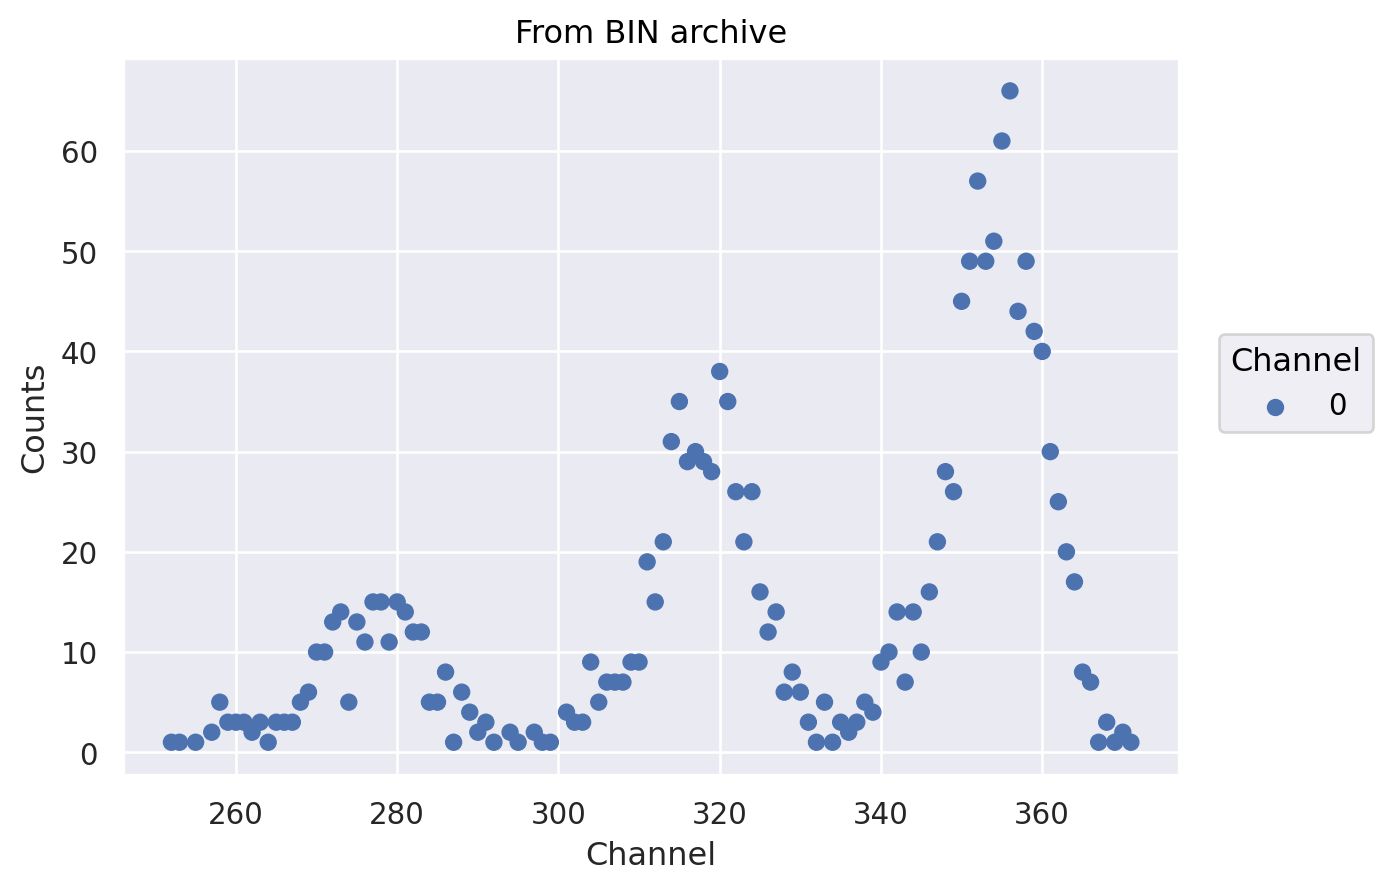

In [4]:
run =  '20251127_run_alpha_7'
pathBIN = glob.glob(path(folder) + run + '/RAW/*.BIN')[0]
print('Analizando...\n', pathBIN)

dfBIN = bin_to_df(pathBIN)

dfBIN_hist = hist_bin(pathBIN)
dfBIN_hist_filt = filter_hist(dfBIN_hist, counts_min= 1, ch_min= 250)


(
    so.Plot(data = dfBIN_hist_filt, x = 'Energy', y = 'Counts', color = dfBIN_hist_filt.Channel.astype(str))
    .add(so.Dot())
    .label(x = 'Channel', y = 'Counts', title = 'From BIN archive')
)

In [5]:
pos_peaks, results_peaks = list(calibration_ch_en(dfBIN_hist_filt, limits_w = (8, 20), limits_h = (10, 520)).values())[0]

Channel_peaks, Counts_peaks = dfBIN_hist_filt[['Energy', 'Counts']].iloc[pos_peaks[[0, 2, 3]]].values.T

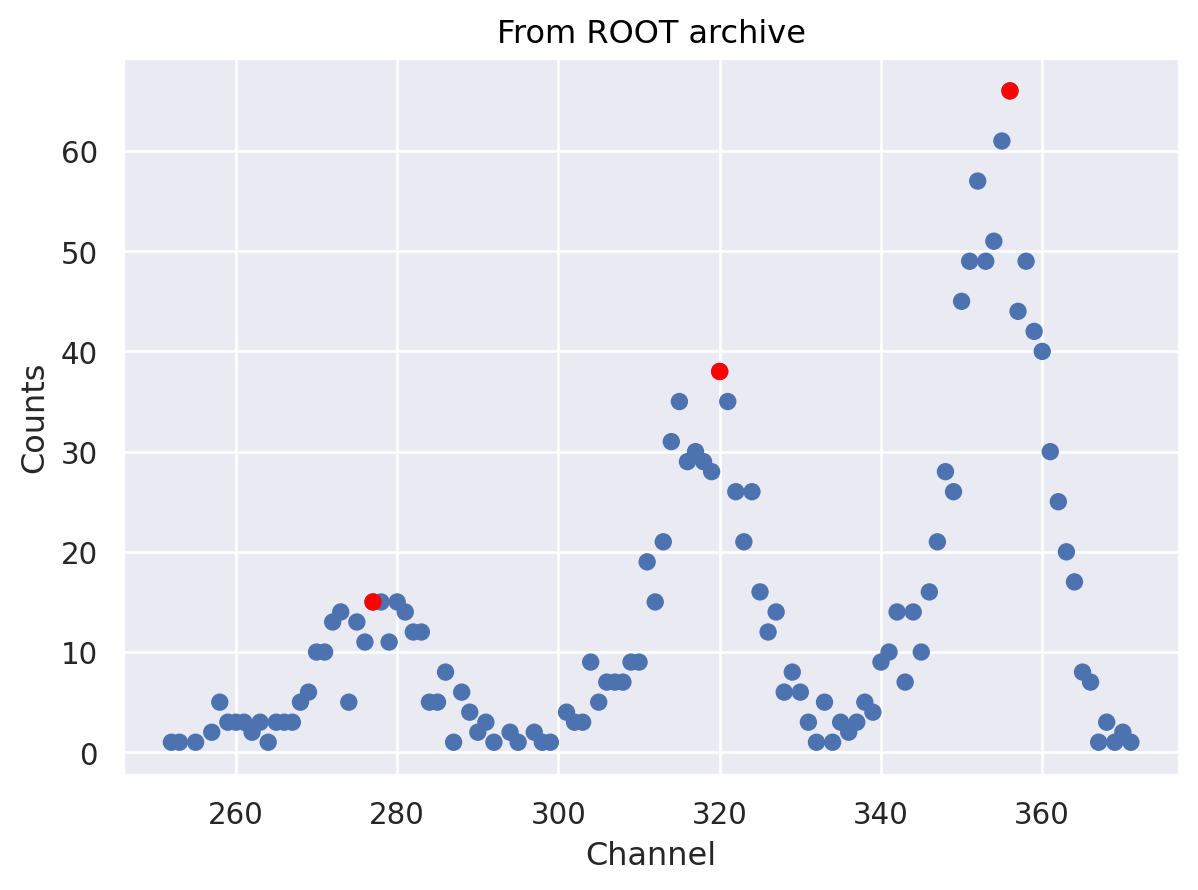

In [6]:
(
    so.Plot(x = dfBIN_hist_filt.Energy, y = dfBIN_hist_filt.Counts)
    .add(so.Dot())
    .add(so.Dot(color = 'red'), x = Channel_peaks, y = Counts_peaks)
    .label(x = 'Channel', y = 'Counts', title = 'From ROOT archive')
)

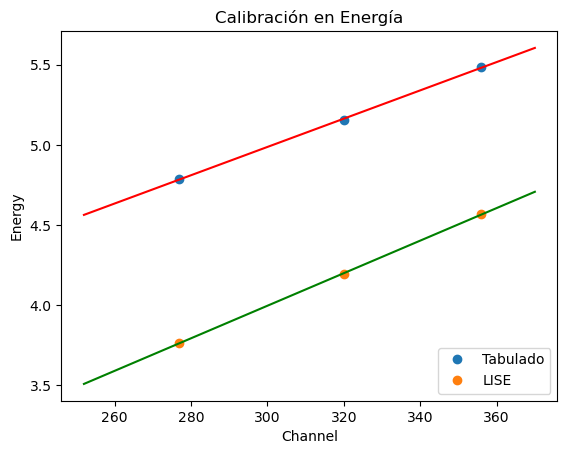

Ajuste Tabulado:
{'coef': np.float64(0.008825804389516296), 'y0': np.float64(2.339336138930324), 'R2': 0.9995444823914298}

Ajuste LISE
{'coef': np.float64(0.010157042403579798), 'y0': np.float64(0.9494461964628167), 'R2': 0.9997908966756047}


In [7]:
run_fit(dfBIN_hist_filt, Channel_peaks)

## Detector 1

Analizando...
 /home/lexi/Documentos/Datos CNEA/CAC_Protonterapia/2025_11_protonterapia/20251127-pterapia/DAQ/20251127_run_alpha/RAW/SDataR_20251127_run_alpha.BIN


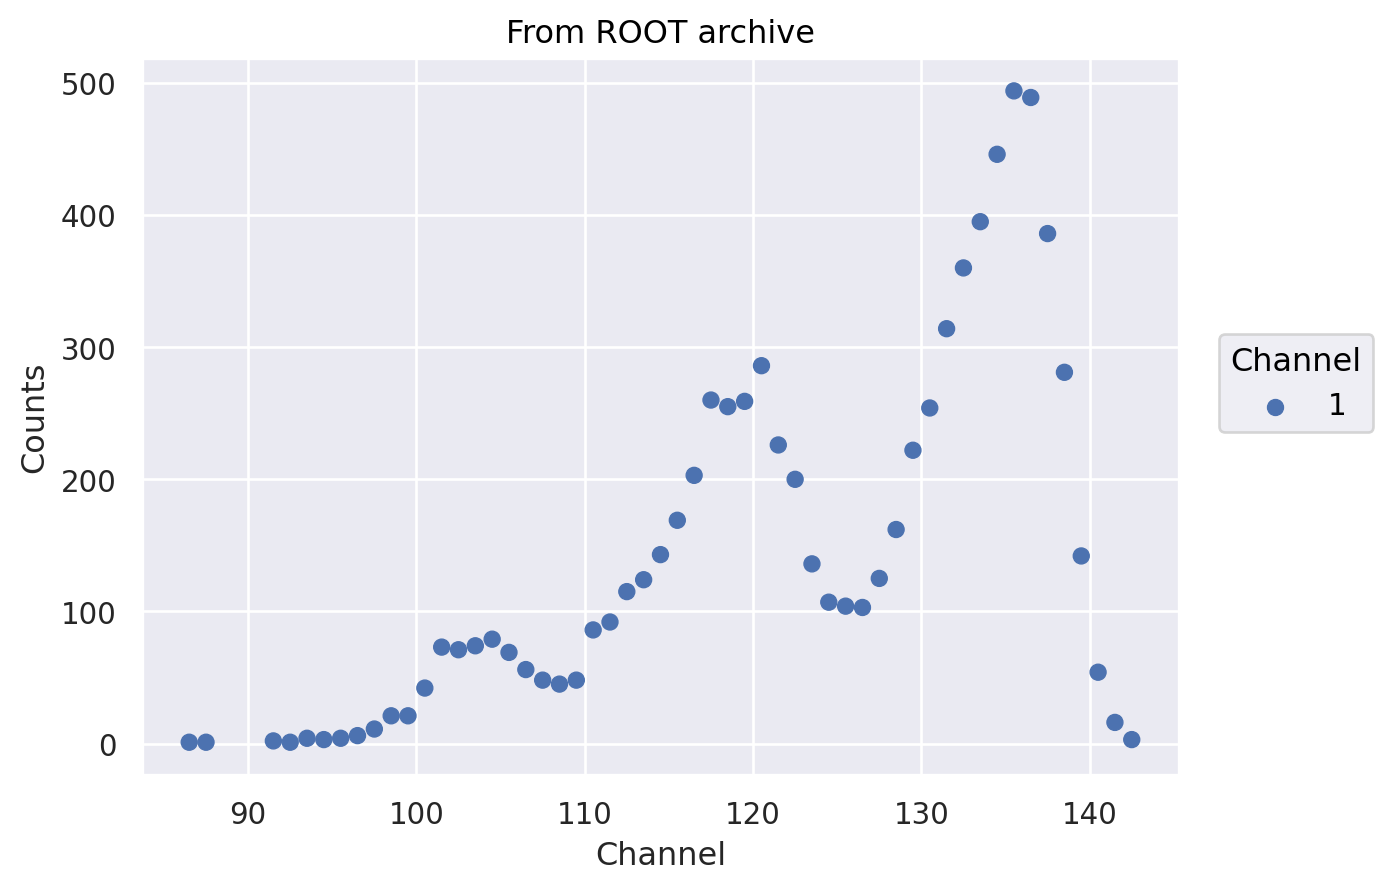

In [8]:
run =  '20251127_run_alpha'
pathBIN = glob.glob(path(folder) + run + '/RAW/*.BIN')[0]
print('Analizando...\n', pathBIN)

pathROOT = glob.glob(path(folder) + run + '/RAW/*.root')[0]
rootfile = ROOT.TFile.Open(pathROOT)

dfROOT = (
    hist_root(rootfile)
    .rename(columns = {
        'bins_center': 'Energy',
        'counts': 'Counts'
        })
)

dfROOT_filt = filter_hist(dfROOT, counts_min= 1, ch_min= 75, ch_max = 150)

(
    so.Plot(data = dfROOT_filt, x = 'Energy', y = 'Counts', color = dfROOT_filt.Channel.astype(str))
    .add(so.Dot())
    .label(x = 'Channel', y = 'Counts', title = 'From ROOT archive')
)


In [9]:
pos_peaks, results_peaks = list(calibration_ch_en(dfROOT_filt, limits_w = (4, 20), limits_h = (30, 520)).values())[0]

Channel_peaks, Counts_peaks = dfROOT_filt[['Energy', 'Counts']].iloc[pos_peaks].values.T

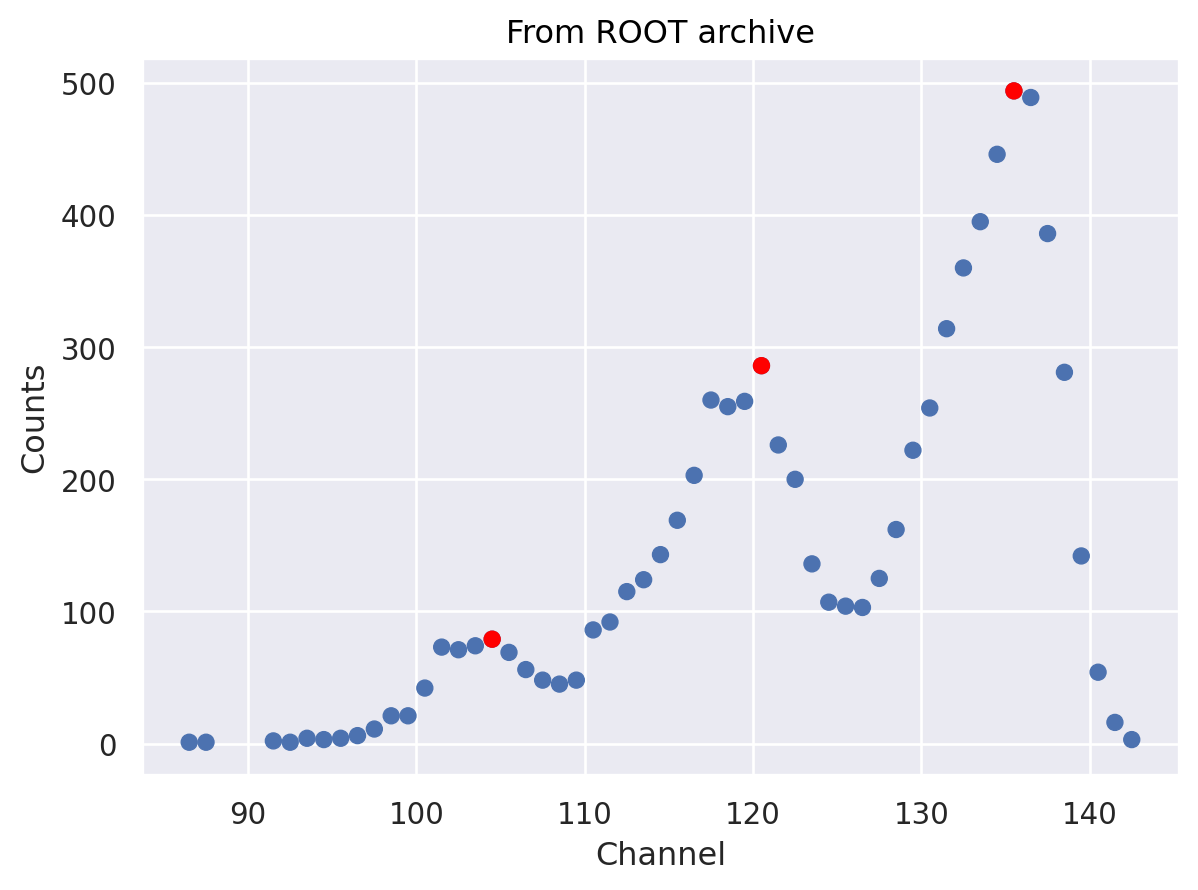

In [10]:
(
    so.Plot(x = dfROOT_filt.Energy, y = dfROOT_filt.Counts)
    .add(so.Dot())
    .add(so.Dot(color = 'red'), x = Channel_peaks, y = Counts_peaks)
    .label(x = 'Channel', y = 'Counts', title = 'From ROOT archive')
)

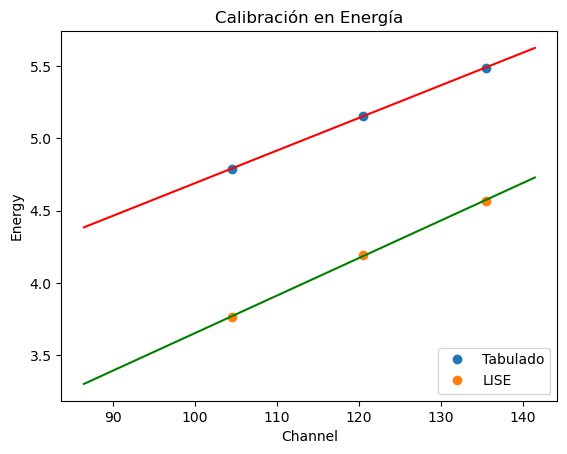

Ajuste Tabulado:
{'coef': np.float64(0.022520804438280154), 'y0': np.float64(2.436750000000002), 'R2': 0.999875759970071}

Ajuste LISE
{'coef': np.float64(0.025911927877947296), 'y0': np.float64(1.0622499999999993), 'R2': 0.9996749506558509}


In [11]:
run_fit(dfROOT_filt, Channel_peaks)

## Resultados

In [12]:
coef_det0 = {'m': 0.008825804389516296, 'b': np.float64(2.339336138930324), 'R2': 0.9995444823914298}

coef_det1 = {'m': np.float64(0.022520804438280154), 'b': np.float64(2.436750000000002), 'R2': 0.999875759970071}

In [16]:
data = pd.DataFrame.from_dict(coef_det0, orient = 'index', columns= [0])
data = pd.concat([data, pd.DataFrame.from_dict(coef_det1, orient = 'index', columns= [1])], axis = 1).T.reset_index(names= ['det'])
data.to_csv('coef_calib_energia.csv', index=False)

In [15]:
coef_det0_LISE = {'m': np.float64(0.010157042403579798), 'b': np.float64(0.9494461964628167), 'R2': 0.9997908966756047}

coef_det1_LISE = {'m': np.float64(0.025911927877947296), 'b': np.float64(1.0622499999999993), 'R2': 0.9996749506558509}

data_LISE = pd.DataFrame.from_dict(coef_det0_LISE, orient = 'index', columns= [0])
data_LISE = pd.concat([data_LISE, pd.DataFrame.from_dict(coef_det1_LISE, orient = 'index', columns= [1])], axis = 1).T.reset_index(names= ['det'])
data_LISE.to_csv('coef_calib_energia_LISE.csv', index=False)